# Data 612 Project 5

Matthew Tillmawitz

## Introduction

For this project we will be implimenting an Alternating Least Squares (ALS) recommender using PySpark as well as the Implicit library and comparing the two models. We will be considering the training time, RMSE of predictions, precision at 10 and recall at 10 of both models. The purpose of this project is to demonstrate the performance overhead of Spark, and evaluate when distributed platforms should be utilized. To this end, we will only be training a single model from each library without cross-validation or hyperparameter tuning as recommendation quality is not the primary focus of our analysis.

The dataset we will be using is generated from the Netflix prize dataset and is the same dataset used in Project 4. The dataset consists of a representative sample of 100,000 ratings, a more detailed analysis of the dataset can be found in [Project 4](https://github.com/Tillmawitz/data_612/blob/main/assignments/Tillmawitz_project_4.ipynb) and will not be repeated here. The ratings are changed from explicit ratings ranging from 1-5 to an implicit binary dataset based on whether the user rated a movie at 4 or higher. The reasoning for this change is the same as for project 4, when generating recommendations the focus is not on correctly guessing how much a user will dislike an item but whether they will like an item at all. Using a binary value to indicate whether a user liked a movie focuses the model on optimizing for items the user will like, and as a result will generate more useful recommendations.

In [46]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import time
import warnings
warnings.filterwarnings('ignore')

import implicit
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import ranking_metrics_at_k

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql.types import IntegerType, FloatType
from pyspark.ml.recommendation import ALS as SparkALS
from pyspark.ml.evaluation import RegressionEvaluator


In [47]:
# Load data
df = pd.read_csv('/Users/matttillman/School/data_612/assignments/netflix_subset/netflix_subset_recommender_100000.csv')

# Convert dataset to implicit ratings, keep only positive interactions
df['implicit_rating'] = (df['rating'] >= 4).astype(int)
df_implicit = df[df['implicit_rating'] == 1].copy().drop('rating', axis=1)

# Train/test split
train_df, test_df = train_test_split(df_implicit, test_size=0.2, random_state=8675309)


## Model Training

We will only be training a single instance of each model, as tuning accuracy is not the primary goal of this analysis. As a result, we will fix the model hyperparameters and ensure they are the same for both models. As Spark uses the JVM, there is additional overhead setting up the Spark session. It should be noted that the ALS implimentation in the PySpark library is optimized for explicit rating predictions, although there is a parameter to indicate the data is implicit. The rest of this section consists of the code for training the models and generating baskets of recommendations with little commentary, which is reserved for the analysis of the results.

In [48]:
# Initialize session, could experiment with memory allocation
spark = SparkSession.builder \
    .appName("ALS_Comparison") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# Create Spark DataFrame
train_spark = spark.createDataFrame(train_df[['user_id', 'movie_id', 'implicit_rating']])
train_spark = train_spark.withColumn("user_id", col("user_id").cast(IntegerType())) \
                         .withColumn("movie_id", col("movie_id").cast(IntegerType())) \
                         .withColumn("implicit_rating", col("implicit_rating").cast(FloatType()))

test_spark = spark.createDataFrame(test_df[['user_id', 'movie_id', 'implicit_rating']])
test_spark = test_spark.withColumn("user_id", col("user_id").cast(IntegerType())) \
                       .withColumn("movie_id", col("movie_id").cast(IntegerType())) \
                       .withColumn("implicit_rating", col("implicit_rating").cast(FloatType()))

In [49]:
# Train spark ALS model
start_time = time.time()

spark_als = SparkALS(
    maxIter=10,
    regParam=0.1,
    rank=50,
    userCol="user_id",
    itemCol="movie_id",
    ratingCol="implicit_rating",
    coldStartStrategy="drop",
    implicitPrefs=True,
    alpha=1.0
)

spark_model = spark_als.fit(train_spark)
spark_train_time = time.time() - start_time
print(f"PySpark ALS training completed in {spark_train_time:.2f} seconds")

PySpark ALS training completed in 3.67 seconds


The use of a RegressionEvaluator instead of the more appropriate BinaryClassificationEvaluator is further evidence the PySpark ALS model is not optimized for the kind of implicit data we have created. The model itself is incompatible with the binary evaluator, and we will see in the results section how this affects the model performance.

In [50]:
# Make predictions
spark_predictions = spark_model.transform(test_spark)

# Calculate RMSE
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="implicit_rating",
    predictionCol="prediction"
)

spark_rmse = evaluator.evaluate(spark_predictions)

print(f"PySpark ALS RMSE: {spark_rmse:.4f}")

PySpark ALS RMSE: 0.8210


In [51]:
# Prepare data for implicit library
# Create user and item mappings
user_ids = df_implicit['user_id'].unique()
movie_ids = df_implicit['movie_id'].unique()

user_map = {user_id: i for i, user_id in enumerate(user_ids)}
movie_map = {movie_id: i for i, movie_id in enumerate(movie_ids)}

# Reverse mappings
user_map_reverse = {i: user_id for user_id, i in user_map.items()}
movie_map_reverse = {i: movie_id for movie_id, i in movie_map.items()}

train_df_mapped = train_df.copy()
train_df_mapped['user_idx'] = train_df_mapped['user_id'].map(user_map)
train_df_mapped['movie_idx'] = train_df_mapped['movie_id'].map(movie_map)

test_df_mapped = test_df.copy()
test_df_mapped['user_idx'] = test_df_mapped['user_id'].map(user_map)
test_df_mapped['movie_idx'] = test_df_mapped['movie_id'].map(movie_map)

train_matrix = csr_matrix(
    (train_df_mapped['implicit_rating'], (train_df_mapped['user_idx'], train_df_mapped['movie_idx'])),
    shape=(len(user_ids), len(movie_ids))
)

test_matrix = csr_matrix(
    (test_df_mapped['implicit_rating'], (test_df_mapped['user_idx'], test_df_mapped['movie_idx'])),
    shape=(len(user_ids), len(movie_ids))
)

In [52]:
start_time = time.time()

implicit_als = AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=10,
    alpha=1.0,
    random_state=8675309
)

implicit_als.fit(train_matrix)
implicit_train_time = time.time() - start_time

print(f"Implicit ALS training completed in {implicit_train_time:.2f} seconds")

100%|██████████| 10/10 [00:00<00:00, 73.15it/s]

Implicit ALS training completed in 0.14 seconds


The Implicit library does not have built in functions for generating RMSE as this is generally a poor metric for sparse datasets. We are implimenting a quick RMSE calculation to provide context in our model evaluation as the Spark model makes heavy use of it as a metric.

In [53]:
def calculate_implicit_rmse(model, train_matrix, test_matrix):
    predictions = []
    actuals = []
    
    # Get test interactions
    test_coo = test_matrix.tocoo()
    
    for user_idx, movie_idx, rating in zip(test_coo.row, test_coo.col, test_coo.data):
        # Get prediction from model
        user_vector = model.user_factors[user_idx]
        item_vector = model.item_factors[movie_idx]
        prediction = np.dot(user_vector, item_vector)
        
        predictions.append(prediction)
        actuals.append(rating)
    
    return np.sqrt(mean_squared_error(actuals, predictions))

implicit_rmse = calculate_implicit_rmse(implicit_als, train_matrix, test_matrix)

Below are functions used to generate baskets of recommendations for each user from both models and put them in a unified format. This makes the evaluation of the models simpler.

In [54]:
# Generate comprehensive recommendations for evaluation
def generate_spark_recommendations_dict(model, train_df, num_recommendations=10):
    unique_users = train_df['user_id'].unique()
    users_df = spark.createDataFrame([(int(user_id),) for user_id in unique_users], ["user_id"])
    
    # Get recommendations for all users in one call
    all_recs = model.recommendForUserSubset(users_df, num_recommendations)
    
    recommendations_dict = {}
    recs_collected = all_recs.collect()
    
    for row in recs_collected:
        user_id = row['user_id']
        recommendations = row['recommendations']
        recommendations_dict[user_id] = [rec['movie_id'] for rec in recommendations]
    
    # Fill in any missing users with empty lists
    for user_id in unique_users:
        if user_id not in recommendations_dict:
            recommendations_dict[user_id] = []
    
    return recommendations_dict

def generate_implicit_recommendations_dict(model, train_matrix, user_map_reverse, movie_map_reverse, num_recommendations=10):
    recommendations_dict = {}
    
    # Get all users that have interactions in the training matrix
    users_with_interactions = np.where(np.array(train_matrix.sum(axis=1)).flatten() > 0)[0]
    
    for user_idx in users_with_interactions:
        try:
            # Get recommendations for this user
            recs = model.recommend(user_idx, train_matrix[user_idx], N=num_recommendations)
            
            # Convert back to original IDs
            user_id = user_map_reverse[user_idx]
            
            # Handle tuple format: (item_ids, scores)
            if isinstance(recs, tuple) and len(recs) == 2:
                movie_indices, scores = recs
                movie_ids = [movie_map_reverse[movie_idx] for movie_idx in movie_indices]
            else:
                # Fallback for other formats
                movie_ids = [movie_map_reverse[movie_idx] for movie_idx in recs]
            
            recommendations_dict[user_id] = movie_ids
            
        except Exception as e:
            # Handle users with no recommendations
            user_id = user_map_reverse[user_idx]
            recommendations_dict[user_id] = []
    
    # Fill in users without interactions with empty lists
    for user_idx in range(train_matrix.shape[0]):
        user_id = user_map_reverse[user_idx]
        if user_id not in recommendations_dict:
            recommendations_dict[user_id] = []
    
    return recommendations_dict

# Prepare data for evaluation
def prepare_evaluation_data(test_df):
    test_interactions = {}
    for _, row in test_df.iterrows():
        user_id = row['user_id']
        movie_id = row['movie_id']
        if user_id not in test_interactions:
            test_interactions[user_id] = []
        test_interactions[user_id].append(movie_id)
    
    return test_interactions

# Model Comparison

Due to library incompatibilities precision at k and recall at k were manually implimented.

In [55]:
# Prepare evaluation data
test_interactions = prepare_evaluation_data(test_df)

# Generate PySpark recommendations
spark_recommendations = generate_spark_recommendations_dict(spark_model, train_df, num_recommendations=10)

# Generate implicit recommendations  
implicit_recommendations = generate_implicit_recommendations_dict(
    implicit_als, train_matrix, user_map_reverse, movie_map_reverse, num_recommendations=10
)

In [56]:
# More library incompatibilities
def precision_at_k(actual_lists, predicted_lists, k=10):
    precisions = []
    for actual, predicted in zip(actual_lists, predicted_lists):
        if len(predicted) == 0:
            precisions.append(0.0)
            continue
        
        predicted_k = predicted[:k]
        actual_set = set(actual)
        relevant_items = len([item for item in predicted_k if item in actual_set])
        precision = relevant_items / len(predicted_k)
        precisions.append(precision)
    
    return np.mean(precisions) if precisions else 0.0

def recall_at_k(actual_lists, predicted_lists, k=10):
    recalls = []
    for actual, predicted in zip(actual_lists, predicted_lists):
        if len(actual) == 0:
            recalls.append(0.0)
            continue
        
        predicted_k = predicted[:k]
        actual_set = set(actual)
        relevant_items = len([item for item in predicted_k if item in actual_set])
        recall = relevant_items / len(actual_set)
        recalls.append(recall)
    
    return np.mean(recalls) if recalls else 0.0

# Get the metrics defined above
def evaluate_recommendations(recommendations_dict, test_interactions, k=10):
    if not recommendations_dict:
        return {'precision@10': 0, 'recall@10': 0}
    
    # Prepare data for evaluation
    actual_lists = []
    predicted_lists = []
    
    for user_id in recommendations_dict.keys():
        if user_id in test_interactions:
            actual_lists.append(test_interactions[user_id])
            predicted_lists.append(recommendations_dict[user_id][:k])
    
    if not actual_lists:
        return {'precision@10': 0, 'recall@10': 0}
    
    # Calculate metrics
    results = {
        'precision@10': precision_at_k(actual_lists, predicted_lists, k=k),
        'recall@10': recall_at_k(actual_lists, predicted_lists, k=k)
    }
    
    return results

In [57]:
# Evaluate PySpark model
spark_metrics = evaluate_recommendations(
    recommendations_dict=spark_recommendations,
    test_interactions=test_interactions,
    k=10
)

# Evaluate implicit model
implicit_metrics = evaluate_recommendations(
    recommendations_dict=implicit_recommendations,
    test_interactions=test_interactions,
    k=10
)

In [58]:
# Compare models with all metrics
all_metrics_comparison = pd.DataFrame({
    'PySpark ALS': [
        spark_train_time,
        spark_rmse,
        spark_metrics['precision@10'],
        spark_metrics['recall@10']
    ],
    'Implicit ALS': [
        implicit_train_time,
        implicit_rmse,
        implicit_metrics['precision@10'],
        implicit_metrics['recall@10']
    ]
}, index=[
    'Training Time (s)',
    'RMSE',
    'Precision@10',
    'Recall@10'
])

print(all_metrics_comparison)

                   PySpark ALS  Implicit ALS
Training Time (s)     3.670587      0.143900
RMSE                  0.820971      0.905926
Precision@10          0.034926      0.088335
Recall@10             0.069879      0.115665


There is a surprisingly large difference in model performance between the two libraries across all tracked metrics. While we anticipated a significant difference in training time due to the overhead associated with PySpark, the gaps in other metrics were unexpected. The PySpark model had significantly worse performance in both precision and recall at 10, with the Implicit model approximately doubling the score in both metrics. The RMSE of the PySpark model is slightly better, indicating the PySpark ALS implimentation likely optimizes for RMSE and may overemphasize predicting negative cases accurately as a result. Another possibility is that the initial random state of the PySpark factor matrices was simply further from the optimal values than the initial state of the Implicit model and did not have enough iterations to converge to the optimal values. It is also possible that optimizations for distributed training result in poorer estimates due to assumed incomplete information available to each node, which again could mean more iterations are required to converge to optimal values.

While the accuracy metrics may seem like little more than an interesting sidenote, they are still relevant when analyzing model performance in terms of training time and resource utilization. If using Spark in a distributed environment as intended, our choice of model implimentations is largely restricted to those defined in PySpark or similar libraries. If it is the case that, for whatever reason, the PySpark implimentations of models such as ALS can achieve similar performance in terms of precision and recall as libraries such as Implicit but require more iterations to converge there are significant performance implications. Requiring more iterations for optimal convergence means longer model training times and potentially more resources required, which can have significant cost implications.

As we cannot make definitive conclusions on whether the PySpark ALS implimentation requires more iterations to converge without conducting tests across many different seeds, iteration numbers, datasets, and platforms we will instead move on and consider the training times involved in each model. It is once again evident the overhead involved in Spark has a significant cost, with the PySpark model taking over ten times as long to train as the Implicit model. It should be noted, the PySpark model only averages out to 1.6 second training times after the initial run of this notebook. The initial execution resulted in training times around 4.6 seconds long, likely due to additional costs associated with initial runs and performance improvements from cacheing. These models were trained using the CPU optimized versions of the models, and both platforms allow for GPU acceleration although Spark requires additional libraries to make full use of this feature. It is possible training times could differ significantly if run on a GPU, however we cannot explore this as we do not have easy access to one. These values should therefore be considered largely in relative terms, with the knowledge that performance may vary significantly depending on the available hardware.

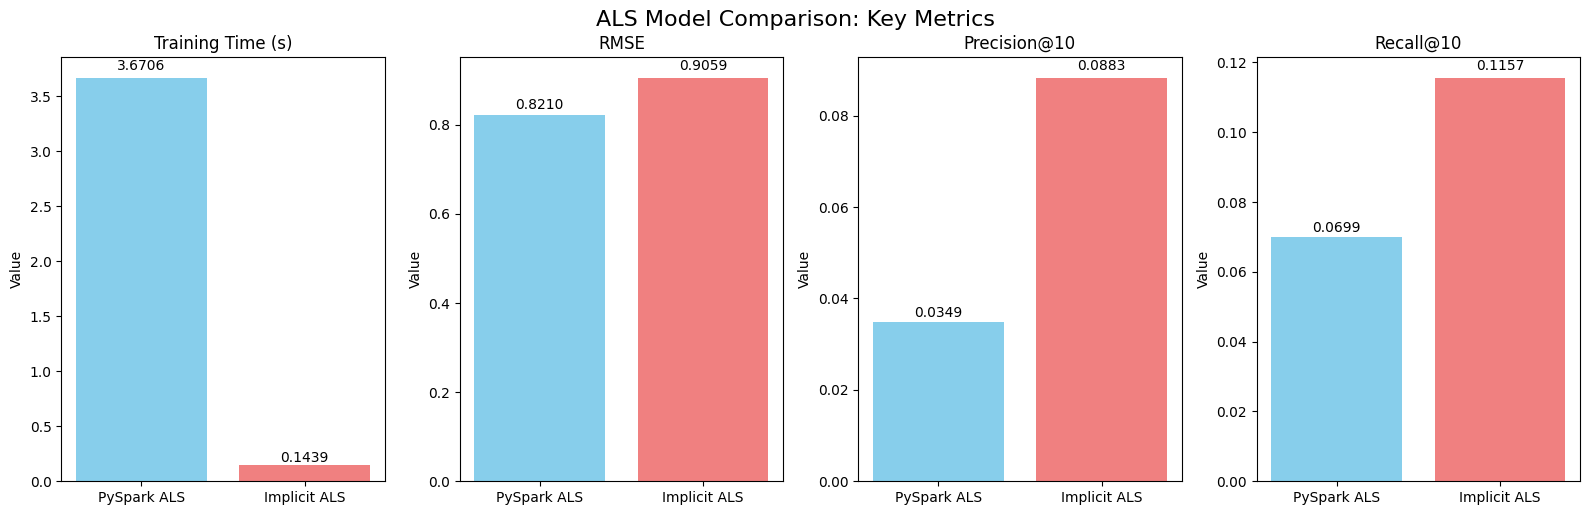

In [59]:
# Visualize comparison (simplified)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Performance metrics
metrics_to_plot = ['Training Time (s)', 'RMSE', 'Precision@10', 'Recall@10']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = all_metrics_comparison.loc[metric]
    bars = ax.bar(['PySpark ALS', 'Implicit ALS'], values, color=['skyblue', 'lightcoral'])
    ax.set_title(metric)
    ax.set_ylabel('Value')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.suptitle('ALS Model Comparison: Key Metrics', fontsize=16, y=1.02)
plt.show()

## Conclusions

As one may expect for a library intended to run on a distributed platform, the PySpark ALS model performed poorly on a single laptop. The overhead associated with managing the JVM as well as the general optimizations for distributed workloads significantly increase training times with little benefit when working with small datasets. If a full dataset can be loaded into memory on a single node and the model does not utilize a memory intensive method such as matrix factorization there is little reason to use a platform such as Spark. It is important to note that this does not necessarily restrict one to using a local environment, as cloud platforms such as AWS, Azure, or GCP can provide access to servers with powerful GPUs and large pools of RAM for relatively little cost. This can dramatically increase the scale of datasets that can be processed using centralized libraries and should not be discounted when considering the scale at which distributed systems make sense. 

For this experiment, we made use of a subset of the full Netflix challenge dataset. This is due largely to the memory-intense nature of matrix factorization models like ALS. The dataset itself takes up a little over 2 GB in text form, and requires significantly less memory when loaded into efficient datatypes and structures. While the dataset itself can be easily loaded into the memory of a consumer grade laptop, or even most modern smartphones theoretically, the model type chosen for this project requires significantly more memory meaning we cannot process the full dataset on the hardware available. In this case, it could be argued that a distributed platform such as Spark would a good choice for model training. However, other model types such as UBCF can be trained on the full dataset with the available hardware. If model training itself is the main factor driving the decision to move to a distributed system it is important to consider whether there would be meaningful return on investment over other model types which may not perform as well but can be trained on less expensive hardware.

Ultimately distributed platforms only become necessary if datasets grow too large to load into memory on appropriate hardware or if the model or data marshaling needed benefit heavily from parallelization. In practice, this tends to be on the order of tens of gigabytes of data at a minimum, or when conducting hyperparameter tuning on large grids of parameters for smaller datasets on the order of several gigabytes. If managing clusters or using serverless compute, it is important to have a degree of knowledge on infrastructure management, especially in a cloud environment. Proper cluster configuration is important, as splitting a cluster across availability zones in AWS can significantly hamper performance in the name of resiliency that is unlikely to be needed. There are similar pitfalls on other cloud platforms, and poor cluster management can significantly increase costs while erasing many of the expected benefits of distributed computing.

In spite of the pitfalls and limitations outlined above, distributed platforms like Spark are still the best tools available for handling large datasets. There is a limit to how large any single instance can be made, and many real world datasets far exceed these limits. Learning how to make the best use of platforms like Spark is a crucial skill, but one should not assume distributed computation is needed for every task and should be aware that they may experience worse performance than centralized options if used when not needed.